# Baseline

In [1]:
import pandas as pd
from blocksnet.relations import generate_adjacency_graph

blocks_gdf = pd.read_pickle('./../data/kemerovo/blocks.pickle')
graph = generate_adjacency_graph(blocks_gdf, 10)

2025-10-27 22:02:44.919 | INFO     | blocksnet.relations.adjacency.core:_generate_adjacency_nodes:9 - Generating nodes
2025-10-27 22:02:44.921 | INFO     | blocksnet.relations.adjacency.core:_generate_adjacency_edges:14 - Generating edges
2025-10-27 22:02:45.450 | SUCCESS  | blocksnet.relations.adjacency.core:generate_adjacency_graph:37 - Adjacency graph successfully generated: 1897 nodes, 6091 edges


In [2]:
from blocksnet.enums import LandUse

for lu in LandUse:
    column = lu.value
    blocks_gdf[column] = blocks_gdf[column].clip(0,1)

In [3]:
FEATURES = ['footprint_area', 'build_floor_area']

## sKNN - spatial K nearest neighbors

In [4]:
import pandas as pd
import numpy as np
from sklearn.neighbors import NearestNeighbors

GEOM_COLS = ['centroid_x', 'centroid_y']

def _compute_centroids(df):
    df = df.copy()
    df[GEOM_COLS[0]] = df.centroid.x
    df[GEOM_COLS[1]] = df.centroid.y
    return df

def sknn_impute(df, blocks_ids : list[int], n_neighbors=5):

    df = _compute_centroids(df)
    
    known = df[~df.index.isin(blocks_ids)].copy()
    unknown = df[df.index.isin(blocks_ids)].copy()
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='ball_tree')
    nbrs.fit(known[GEOM_COLS])
    
    # Для каждого квартала с пропусками находим соседей
    _, indices = nbrs.kneighbors(unknown[GEOM_COLS])
    
    # Импутация
    imputed_values = []
    for idx_list in indices:
        neighbors_values = known.iloc[idx_list][FEATURES]
        imputed_values.append(neighbors_values.mean(axis=0))
    
    imputed_values = pd.DataFrame(imputed_values, columns=FEATURES, index=unknown.index)
    
    # Объединяем результат
    df.loc[unknown.index, FEATURES] = imputed_values
    return df[FEATURES].copy()

sknn_impute(blocks_gdf, [0,1,2,3])

,footprint_area,build_floor_area
0,29579.364209,177567.309342
1,1984.644176,2841.524176
2,6671.401000,6976.801000
3,8447.471315,8873.671315
4,0.000000,0.000000
...,...,...
1892,5367.409964,5367.409964
1893,3688.160818,3688.160818
1894,5523.222991,5523.222991
1895,5068.469592,5068.469592


## IDW -- Inverse Distance Weighting

In [5]:
def idw_impute(df, blocks_ids : list[int], power=2.0, n_neighbors=5):

    df = _compute_centroids(df)
    
    known = df[~df.index.isin(blocks_ids)].copy()
    unknown = df[df.index.isin(blocks_ids)].copy()
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors, algorithm='ball_tree')
    nbrs.fit(known[GEOM_COLS])
    
    # Для каждого квартала с пропусками находим соседей
    distances, indices = nbrs.kneighbors(unknown[GEOM_COLS])
    
    # Импутация
    imputed_values = []
    for i, idx_list in enumerate(indices):
        d = distances[i]
        d = np.clip(d, 1e-6, None)
        weights = 1 / (d ** power)
        weights /= weights.sum()

        neighbors_values = known.iloc[idx_list][FEATURES].values
        weighted_mean = (neighbors_values * weights[:, None]).sum(axis=0)
        imputed_values.append(weighted_mean)
    
    imputed_values = pd.DataFrame(imputed_values, columns=FEATURES, index=unknown.index)
    
    # Объединяем результат
    df.loc[unknown.index, FEATURES] = imputed_values
    return df[FEATURES].copy()

idw_impute(blocks_gdf, [0,1,2,3])

,footprint_area,build_floor_area
0,26736.944584,162184.459088
1,2352.873304,3976.722921
2,4328.922403,4516.062377
3,10873.520722,11172.243414
4,0.000000,0.000000
...,...,...
1892,5367.409964,5367.409964
1893,3688.160818,3688.160818
1894,5523.222991,5523.222991
1895,5068.469592,5068.469592


## GNN

In [6]:
from model import MultiScaleGNN
from blocksnet.machine_learning.strategy.torch.graph import TorchGraphImputationStrategy
from blocksnet.preprocessing.imputing.development import DevelopmentImputer

strategy = TorchGraphImputationStrategy(MultiScaleGNN)
strategy.load('gnn')
imputer = DevelopmentImputer(strategy)

In [7]:
def gnn_impute(df, blocks_ids : list[int], graph):

    df = df.copy()
    result_df = imputer.run(df, graph, blocks_ids)
    df.loc[blocks_ids, FEATURES] = result_df.loc[blocks_ids, FEATURES]

    return df[FEATURES]

gnn_impute(blocks_gdf, [0,1,2,3], graph)

,footprint_area,build_floor_area
0,16557.994141,17908.427734
1,4281.447754,12172.852539
2,12391.866211,-5508.891113
3,3281.508789,15711.540039
4,0.000000,0.000000
...,...,...
1892,5367.409964,5367.409964
1893,3688.160818,3688.160818
1894,5523.222991,5523.222991
1895,5068.469592,5068.469592


## Comparison

In [8]:
def _r2_robust(diff_df, true_df):
    residuals_sq = diff_df**2
    total_sq = (true_df - true_df.mean())**2
    return 1 - residuals_sq.median() / total_sq.median()

def _r2(diff_df, true_df):
    return 1 - (np.square(diff_df).sum() / np.square(true_df - true_df.mean()).sum())

def _rmse(diff_df):
    return np.sqrt((diff_df**2).mean())

def _mae(diff_df):
    return diff_df.abs().mean()

def metrics(true_df, pred_df, blocks_ids : list[int]):
    true_df = true_df.loc[blocks_ids, FEATURES].copy()
    pred_df = pred_df.loc[blocks_ids, FEATURES].copy()
    diff_df = true_df - pred_df

    results = {
        'mae': _mae(diff_df),
        'rmse': _rmse(diff_df),
        'r2': _r2(diff_df, true_df),
        'r2_robust': _r2_robust(diff_df, true_df),
    }

    return pd.DataFrame.from_dict(results)

In [9]:
from tqdm import tqdm

N_EXPERIMENTS = 2

METHODS = {
    'sknn': lambda blocks_ids : sknn_impute(blocks_gdf, blocks_ids),
    'idw': lambda blocks_ids : idw_impute(blocks_gdf, blocks_ids),
    'gnn': lambda blocks_ids : gnn_impute(blocks_gdf, blocks_ids, graph)    
}

def _experiment(missing_rate : float, methods : dict) -> dict[str, pd.DataFrame]:
    n = int(len(blocks_gdf)*missing_rate)
    blocks_ids = blocks_gdf.sample(n).index.to_list()
    return {method_name : metrics(blocks_gdf, method_func(blocks_ids), blocks_ids) for method_name, method_func in methods.items()}

results = {method:{} for method in METHODS}
for i in range(9):

    missing_rate = 0.1 * (i+1)
    dfs_dict = {method_name:[] for method_name in METHODS}

    for _ in tqdm(range(N_EXPERIMENTS), desc=f'{round(missing_rate,1)}'):
        results_dict = _experiment(missing_rate, METHODS)
        for method_name, result_df in results_dict.items():
            dfs_dict[method_name].append(result_df)
        
    for method_name, dfs in dfs_dict.items():
        df = sum(dfs) / len(dfs)
        results[method_name][missing_rate] = df

0.9: 100%|██████████| 2/2 [00:06<00:00,  3.01s/it]


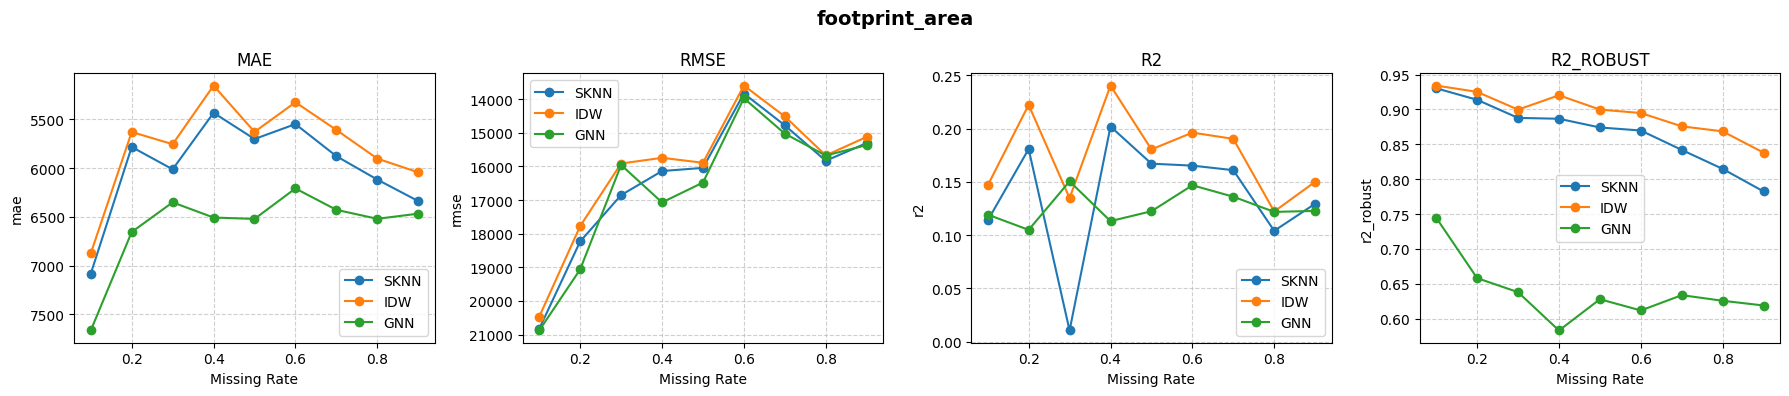

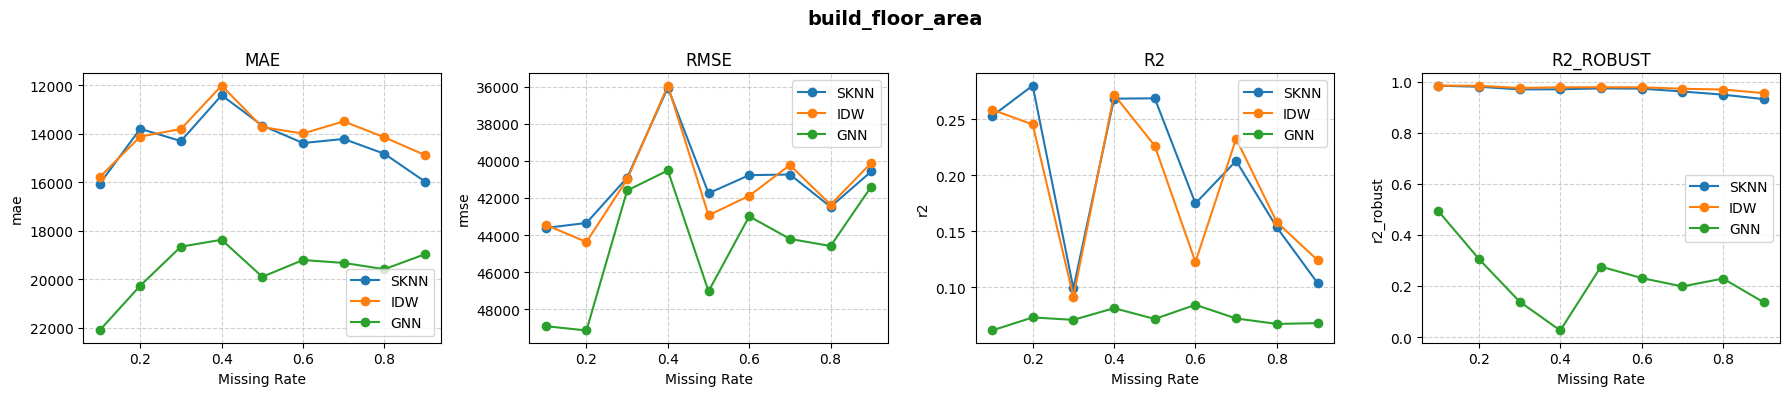

In [10]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_imputation_results(results: dict[str, dict[float, pd.DataFrame]]):
    metrics = ["mae", "rmse", "r2", "r2_robust"]
    variables = FEATURES

    for var in variables:
        fig, axes = plt.subplots(1, len(metrics), figsize=(18, 4))
        fig.suptitle(f"{var}", fontsize=14, fontweight="bold")

        for i, metric in enumerate(metrics):
            ax = axes[i]
            for method, method_results in results.items():
                # Собираем значения метрики для всех missing_rate
                x = sorted(method_results.keys())
                y = [method_results[mr].loc[var, metric] for mr in x]
                ax.plot(x, y, marker="o", label=method.upper())

            ax.set_title(metric.upper())
            ax.set_xlabel("Missing Rate")
            ax.set_ylabel(metric)
            ax.grid(True, linestyle="--", alpha=0.6)
            if metric in ["mae", "rmse"]:
                ax.invert_yaxis()  # для MAE/RMSE меньше — лучше
            ax.legend()

        plt.tight_layout()
        plt.show()

plot_imputation_results(results)